# The equilibrium structure factors can tell us about the defect density(!)

In [1]:
import sys

sys.path.append("../../src")

from equilibrium_critical_correlations import sigma_general as sigma_x

from equilibrium_z_projectors import sigma_general as sigma_z
from equilibrium_critical_correlations import P_n, P_n_correlations
import kibble_zurek as kz

from common_imports import *

from numpy.fft import fft, fftfreq, fftshift

foldername = "Figures/"




/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0.5, 0, 'r')

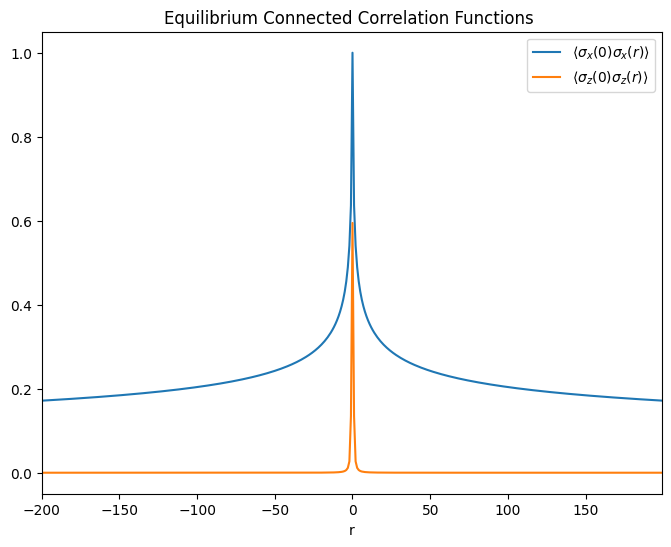

In [36]:
r = np.arange(-200,200)

xx_lab = r"$\langle \sigma_x (0) \sigma_x (r) \rangle $"
zz_lab = r"$\langle \sigma_z(0) \sigma_z (r) \rangle $"

C_xx = array([sigma_x([0,ri]) for ri in r])
C_zz = array([sigma_z([0,ri])- sigma_z([0])**2 for ri in r])


plt.figure(figsize=(8,6))

plot(r,C_xx,label= xx_lab)
plot(r,C_zz,label= zz_lab)
#plot(r,r**(-2.)/6.28,"--k",label=r"$r^{-2}$")
#plot(r,r**(-1/4)/2,ls="-.", color="black", label=r"$r^{-1/4}$")
legend()
xlim(min(r),max(r))
#loglog()
title("Equilibrium Connected Correlation Functions ")
xlabel("r")

Calculate Correlation Lengths

In [37]:
L = 500
taus = np.logspace(0,2,20)
#This is slightly naive. I'm not really sure if we should go to 0 or to the critical point, but I checked and both defects scale the same way with tau (up to a consant in front) so maybe it doesn't matter.
states_g0 = [kz.state(L,tau,tau) for tau in taus]
rhos_g0 = array([1/2*(1-kz.sigma_general([0,1],s)) for s in states_g0])
xis = 1/rhos_g0

KeyboardInterrupt: 

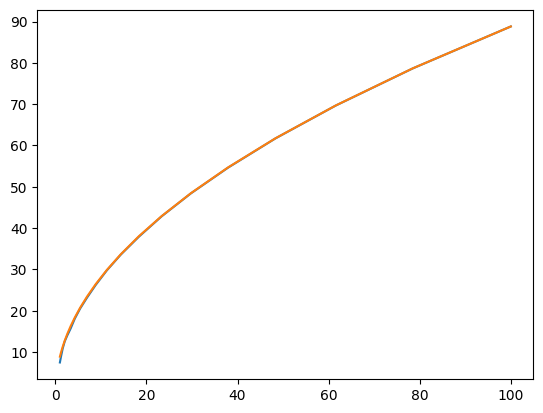

In [4]:
plot(taus,xis)
plot(taus,6.28*sqrt(2)*taus**(1/2))

In [5]:
cut_offs = 1/xis

XX= 1.0776644660950343


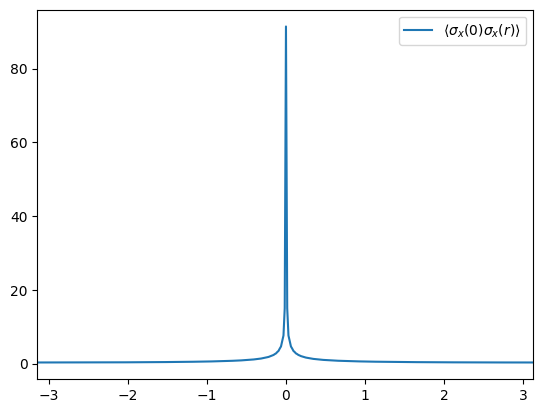

In [38]:
def K(r):
    return fftshift(fftfreq(len(r),1))*2*pi

def FT(x):
    return fftshift(fft(x))


k = K(r)
F_xx = FT(C_xx)

plot(k,abs(F_xx),label = xx_lab)
xlim(min(k),max(k))
legend()


dk = k[1]-k[0]
print(f"XX= {np.real(sum(F_xx)*dk)}")


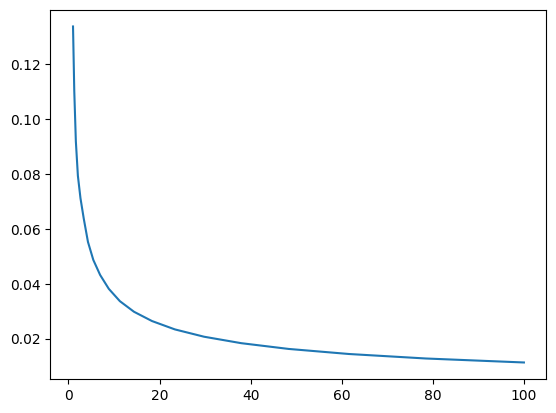

In [8]:
plot(taus,cut_offs)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


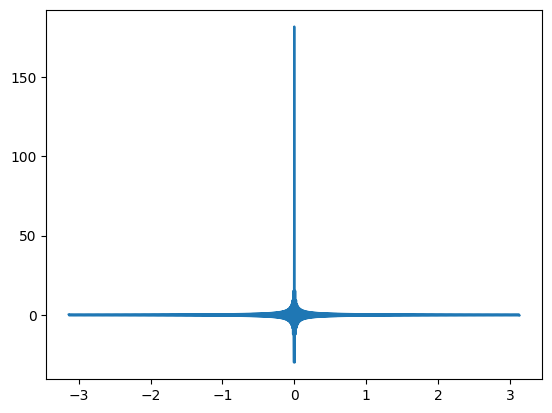

In [9]:
plot(k,F_xx)

In [10]:
sum(abs(F_xx)[ abs(k)< cut_offs[]])*dk

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4047334882.py, line 1)

In [11]:
def PP_cc(n,r):
    return array([P_n_correlations(n,ri)-P_n(n)**2 for ri in tqdm(r)])
r = np.arange(-200,200)

n = np.arange(1,6)
print(n)
Pn = [PP_cc(ni,r) for ni in (n)]


[1 2 3 4 5]


100%|██████████| 400/400 [02:49<00:00,  2.36it/s]


In [ ]:
Fn = [FT(P) for P in Pn]
k = K(r)
cutoffs = k[k>0]
dk = k[1]-k[0]

[]

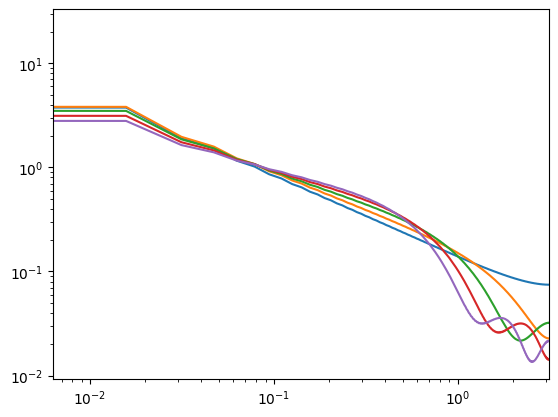

In [18]:
for f in Fn:
    plot(k,abs(f))
xlim(dk,k.max())
loglog()

In [52]:
taus = array([0.01,0.1,0.5,1,5,10,100])

states = [kz.state(500,t,0) for t in taus]


In [53]:
import equilibrium_critical_correlations as eq

In [54]:
#Find rho

rhos = array([sigma_x([0,1])-kz.sigma_general([0,1],s) for s in states])


#Find Deltas:

deltas = [    array([eq.P_n(ni)-kz.P_n(ni,s) for s in states]) for ni in n]


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


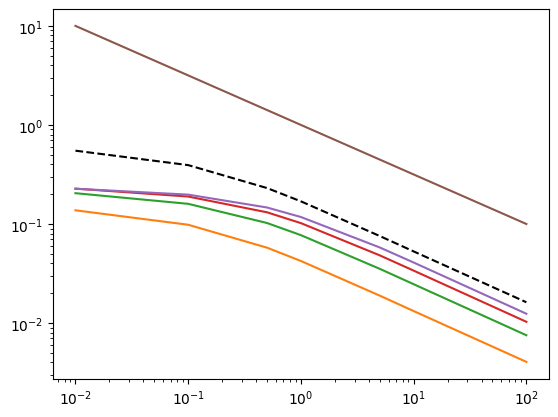

In [56]:
plot(taus,rhos,"--k")

for d,ni in zip(deltas,n):
    plot(taus,d,label=ni)
loglog()
plot(taus,taus**(-1/2))

[]

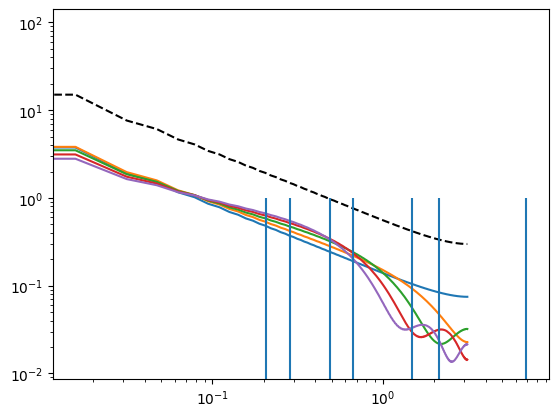

In [50]:
for f in Fn:
    plot(k,abs(f))

plot(k,abs(F_xx),"--k")
for rho in rhos:
    plt.vlines(1/rho/2/pi/sqrt(2),0,1)
#ylim(0,10)
#xlim(-1,1)
loglog()